# Notebook criado para testar o modelo darts


In [3]:
import pandas as pd
import numpy as np
from darts import TimeSeries, concatenate
from darts.models import ARIMA, RegressionModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.missing_values import fill_missing_values
from darts.metrics import mae, rmse, r2_score, mase

In [1]:
import torch
import pytorch_lightning as pl
print(torch.__version__, pl.__version__)

2.6.0+cpu-cxx11-abi 2.5.2


In [2]:
from darts.models import RNNModel
print(type(RNNModel))

<class 'darts.models.forecasting.forecasting_model.ModelMeta'>


# Janelas temporais


In [4]:
TRAIN_END  = pd.Timestamp("2017-12-31 23:00")
VAL_END    = pd.Timestamp("2018-12-31 23:00")
TEST_START = pd.Timestamp("2019-01-01 00:00")
TEST_END   = pd.Timestamp("2019-08-31 23:00")

TARGET = "MP2.5"
COVS   = ["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"]

In [5]:
DATA_PATH = "../data/data_interpolacao_gaps_maiores_medias/pm25_2013_2019_interp_12h_media_sazonal_all_features.csv"

df = pd.read_csv(DATA_PATH, index_col='time', parse_dates=True)

# sanity check
print(df.shape)
print(df.index.min(), "→", df.index.max())
print("colunas:", list(df.columns))
print("NaN:", df[[TARGET] + COVS].isna().sum().to_dict())
df.head(2)

(55008, 9)
2013-05-09 03:00:00+00:00 → 2019-08-18 02:00:00+00:00
colunas: ['MP2.5', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'mes', 'hora', 'dia_semana', 'MP2.5_imputado_media']
NaN: {'MP2.5': 0, 'temperature_2m': 0, 'relative_humidity_2m': 0, 'precipitation': 0, 'wind_speed_10m': 0}


,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,mes,hora,dia_semana,MP2.5_imputado_media
time,,,,,,,,,
2013-05-09 03:00:00+00:00,26.0,10.301001,91.64832,0.0,7.421590,5,3,3,0
2013-05-09 04:00:00+00:00,21.0,9.751000,92.54831,0.0,7.993298,5,4,3,0


In [6]:
df = df.sort_index()
df.index = df.index.tz_localize(None)   # tira o UTC, como no SARIMAX

target = TimeSeries.from_series(df[TARGET], freq="h")
covs   = TimeSeries.from_dataframe(df, value_cols=COVS, freq="h")

target = fill_missing_values(target)
covs   = fill_missing_values(covs)

print("target:", len(target), "pontos |", target.start_time(), "→", target.end_time())
print("covs:", covs.n_components, "componentes")

target: 55008 pontos | 2013-05-09 03:00:00 → 2019-08-18 02:00:00
covs: 4 componentes


# Guardado em unidade real p/ o MASE e treino+val para o modelo final

In [7]:
# fatias
y_train = target.drop_after(TRAIN_END)
y_fit   = target.drop_after(VAL_END)
c_fit   = covs.drop_after(VAL_END)

# scalers ajustados apenas no treino
scaler_y = Scaler().fit(y_train)
scaler_c = Scaler().fit(covs.drop_after(TRAIN_END))

y_all_s = scaler_y.transform(target)
c_all_s = scaler_c.transform(covs)
y_fit_s = y_all_s.drop_after(VAL_END)
y_train_real = y_train

# Encoders

In [8]:
add_encoders = {
    "cyclic": {"future": ["hour", "dayofweek", "month"]},
    "datetime_attribute": {"future": ["dayofyear"]},
    "transformer": Scaler(),
}

# avaliar

In [9]:
def avaliar(model, nome, future_cov_s):
    hf = model.historical_forecasts(
        series=y_all_s,
        future_covariates=future_cov_s,
        start=TEST_START,
        forecast_horizon=24,
        stride=24,
        retrain=False,
        last_points_only=False,
        verbose=True,
    )
    pred_s  = concatenate(hf)
    pred    = scaler_y.inverse_transform(pred_s)
    actual  = target.slice_intersect(pred)
    insample = target.drop_after(pred.start_time())
    return {
        "modelo": nome,
        "MAE":  round(mae(actual, pred), 4),
        "RMSE": round(rmse(actual, pred), 4),
        "R2":   round(r2_score(actual, pred), 4),
        "MASE": round(mase(actual, pred, insample, m=24), 4),
    }

resultados = []

In [10]:
from darts.models import XGBModel

xgb = XGBModel(
    lags=[-1, -24, -48, -168],       # lags de PM2.5 (t-1, t-24, t-48, t-168)
    lags_future_covariates=[0],      # meteo no instante previsto
    add_encoders=add_encoders,
)
xgb.fit(y_fit_s, future_covariates=c_all_s)
resultados.append(avaliar(xgb, "XGBoost", c_all_s))
resultados[-1]

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

{'modelo': 'XGBoost',
 'MAE': 6.8272,
 'RMSE': 9.5479,
 'R2': 0.452,
 'MASE': 0.6836}

In [11]:
tabela = pd.DataFrame(resultados).set_index("modelo")
tabela.sort_values("MAE")

,MAE,RMSE,R2,MASE
modelo,,,,
XGBoost,6.8272,9.5479,0.452,0.6836


In [12]:
import matplotlib.pyplot as plt
import numpy as np

def walk_forward_pred(model, future_cov_s):
    hf = model.historical_forecasts(
        series=y_all_s, future_covariates=future_cov_s,
        start=TEST_START, forecast_horizon=24, stride=24,
        retrain=False, last_points_only=False, verbose=False,
    )
    pred   = scaler_y.inverse_transform(concatenate(hf))
    actual = target.slice_intersect(pred)
    return pred, actual, hf

pred_xgb, actual_xgb, hf_xgb = walk_forward_pred(xgb, c_all_s)

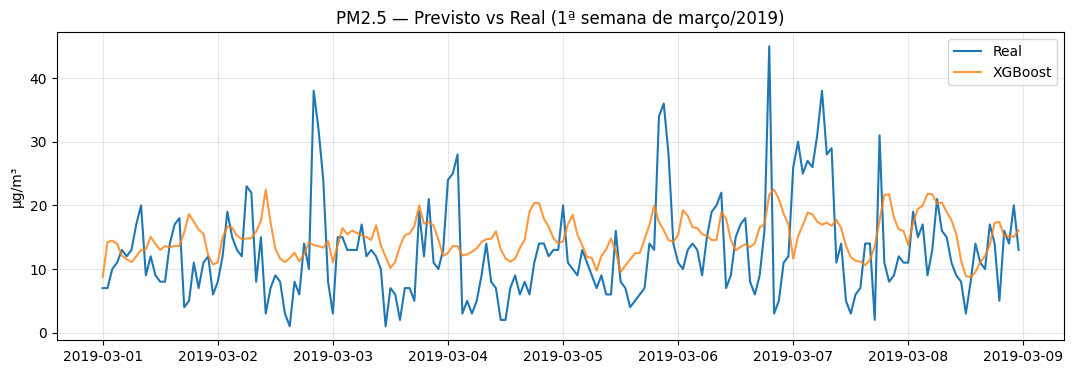

In [13]:
janela = slice("2019-03-01", "2019-03-08")
ps, as_ = pred_xgb.to_series(), actual_xgb.to_series()

plt.figure(figsize=(13, 4))
plt.plot(as_[janela], label="Real", lw=1.5)
plt.plot(ps[janela], label="XGBoost", lw=1.5, alpha=0.8)
plt.title("PM2.5 — Previsto vs Real (1ª semana de março/2019)")
plt.ylabel("µg/m³"); plt.legend(); plt.grid(alpha=0.3); plt.show()

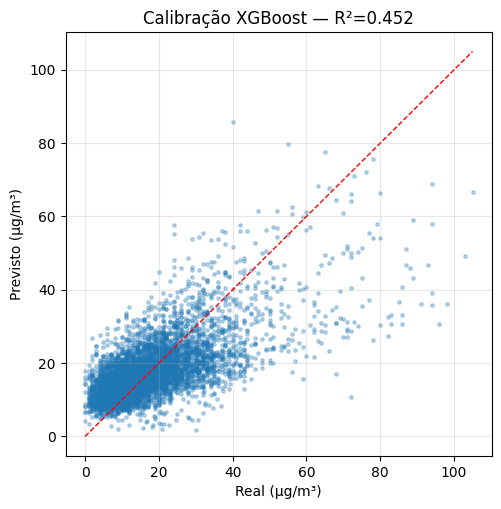

In [14]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(as_, ps, s=6, alpha=0.3)
lim = max(as_.max(), ps.max())
plt.plot([0, lim], [0, lim], 'r--', lw=1)
plt.xlabel("Real (µg/m³)"); plt.ylabel("Previsto (µg/m³)")
plt.title(f"Calibração XGBoost — R²={r2_score(actual_xgb, pred_xgb):.3f}")
plt.grid(alpha=0.3); plt.show()


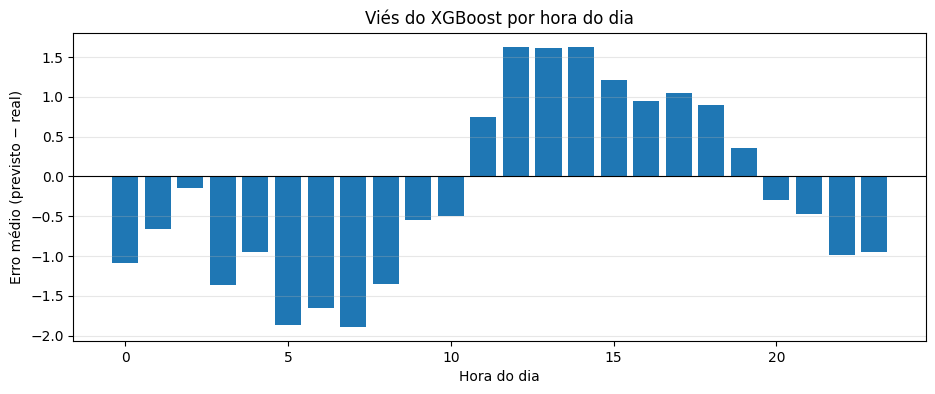

In [15]:
resid = (ps - as_)
por_hora = resid.groupby(resid.index.hour).mean()

plt.figure(figsize=(11, 4))
plt.bar(por_hora.index, por_hora.values)
plt.axhline(0, color='k', lw=0.8)
plt.xlabel("Hora do dia"); plt.ylabel("Erro médio (previsto − real)")
plt.title("Viés do XGBoost por hora do dia")
plt.grid(alpha=0.3, axis='y'); plt.show()

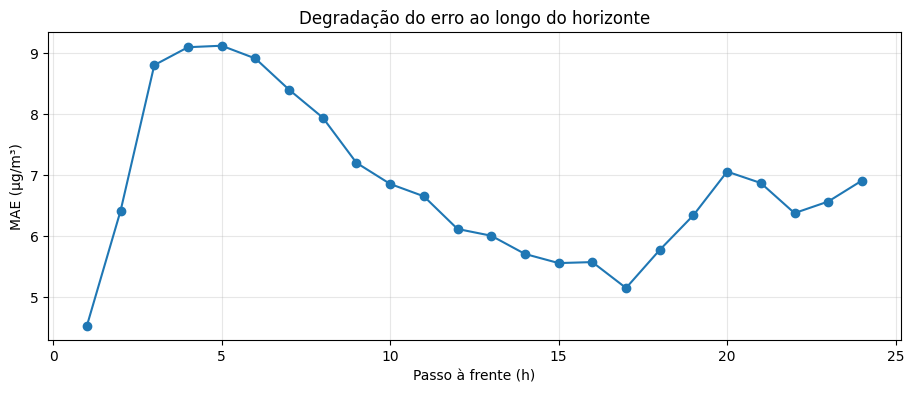

In [16]:
errs = []
for fc in hf_xgb:
    pr = scaler_y.inverse_transform(fc)
    ac = target.slice_intersect(pr)
    n = min(len(pr), len(ac))
    errs.append(np.abs(pr.values().flatten()[:n] - ac.values().flatten()[:n]))
mae_h = np.vstack([e for e in errs if len(e) == 24]).mean(axis=0)

plt.figure(figsize=(11, 4))
plt.plot(range(1, 25), mae_h, marker='o')
plt.xlabel("Passo à frente (h)"); plt.ylabel("MAE (µg/m³)")
plt.title("Degradação do erro ao longo do horizonte")
plt.grid(alpha=0.3); plt.show()

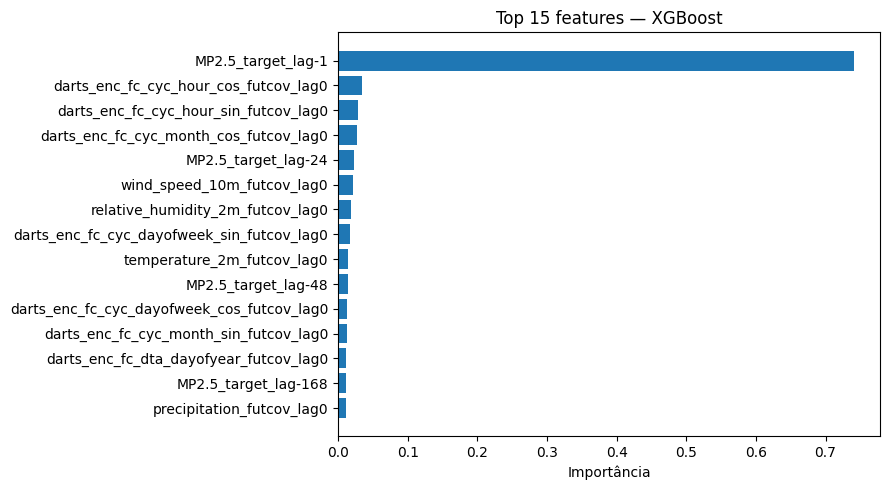

In [17]:
try:
    nomes = xgb.lagged_feature_names
    imp = xgb.model.feature_importances_
    ordem = np.argsort(imp)[::-1][:15]
    plt.figure(figsize=(9, 5))
    plt.barh([nomes[i] for i in ordem][::-1], imp[ordem][::-1])
    plt.xlabel("Importância"); plt.title("Top 15 features — XGBoost")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Não consegui extrair nomes das features:", e)

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]

   meses      MAE      R2
0      6  10.9530 -0.1775
1     12   7.8647  0.2967
2     24   6.9990  0.4438
3     36   7.1151  0.3723
4     48   6.9787  0.3789
5     66   6.7895  0.4553


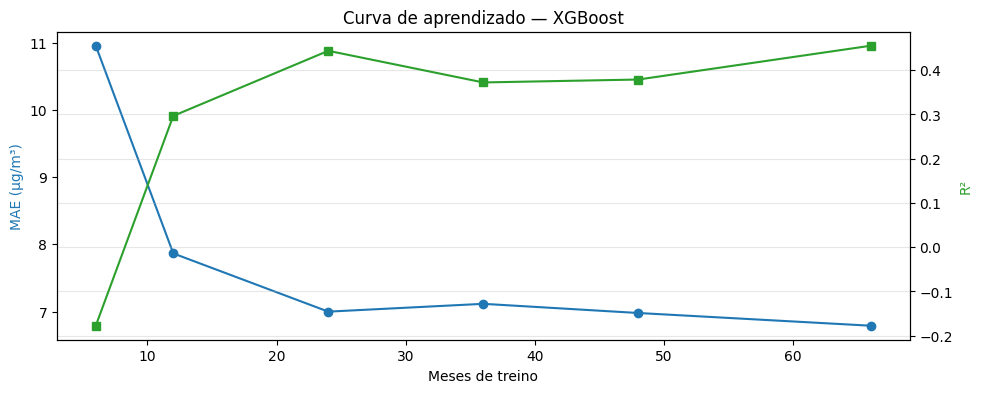

In [18]:
meses = [6, 12, 24, 36, 48, 66]
lc = []
for m in meses:
    ini = VAL_END - pd.DateOffset(months=m)
    y_tr = y_all_s.slice(ini, VAL_END)
    mdl = XGBModel(lags=[-1, -24, -48, -168],
                   lags_future_covariates=[0], add_encoders=add_encoders)
    mdl.fit(y_tr, future_covariates=c_all_s)
    r = avaliar(mdl, f"{m}m", c_all_s)
    lc.append({"meses": m, "MAE": r["MAE"], "R2": r["R2"]})
lc_df = pd.DataFrame(lc); print(lc_df)

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(lc_df["meses"], lc_df["MAE"], 'o-', color='tab:blue', label="MAE")
ax1.set_xlabel("Meses de treino"); ax1.set_ylabel("MAE (µg/m³)", color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(lc_df["meses"], lc_df["R2"], 's-', color='tab:green', label="R²")
ax2.set_ylabel("R²", color='tab:green')
plt.title("Curva de aprendizado — XGBoost"); plt.grid(alpha=0.3); plt.show()

# Testando dart LSTM

In [19]:
from darts.models import RNNModel

lstm = RNNModel(
    model="LSTM",
    input_chunk_length=168,     # lookback de 1 semana
    training_length=192,
    hidden_dim=32,
    n_rnn_layers=1,
    n_epochs=20,                # baixo p/ validar o pipeline; subimos depois
    add_encoders=add_encoders,
    random_state=42,
)
lstm.fit(y_fit_s, future_covariates=c_all_s)
resultados.append(avaliar(lstm, "LSTM", c_all_s))
resultados[-1]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 5.9 K  | train
6 | V               | Linear           | 33     | train
-------------------------------------------------------------
5.9 K     Trainable params
0         Non-trainable params
5.9 K     Total params
0.024     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Generating TimeSeries:   0%|          | 0/229 [00:00<?, ?it/s]

{'modelo': 'LSTM',
 'MAE': 7.1143,
 'RMSE': 10.1073,
 'R2': 0.3859,
 'MASE': 0.7123}

# Gráfico 1 — Previsto vs Real (LSTM)

In [20]:
pred_lstm, actual_lstm, hf_lstm = walk_forward_pred(lstm, c_all_s)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


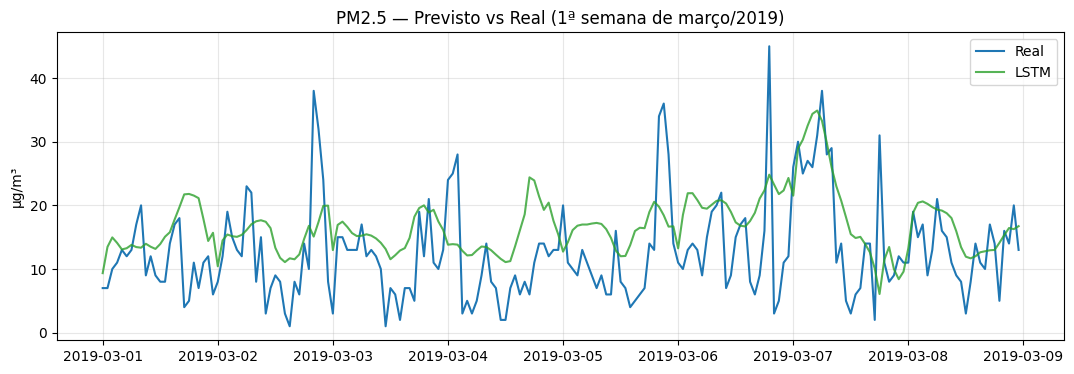

In [21]:
janela = slice("2019-03-01", "2019-03-08")
ps_l, as_l = pred_lstm.to_series(), actual_lstm.to_series()

plt.figure(figsize=(13, 4))
plt.plot(as_l[janela], label="Real", lw=1.5)
plt.plot(ps_l[janela], label="LSTM", lw=1.5, alpha=0.8, color='tab:green')
plt.title("PM2.5 — Previsto vs Real (1ª semana de março/2019)")
plt.ylabel("µg/m³"); plt.legend(); plt.grid(alpha=0.3); plt.show()

# Gráfico 2 — Dispersão Real × Previsto (LSTM)

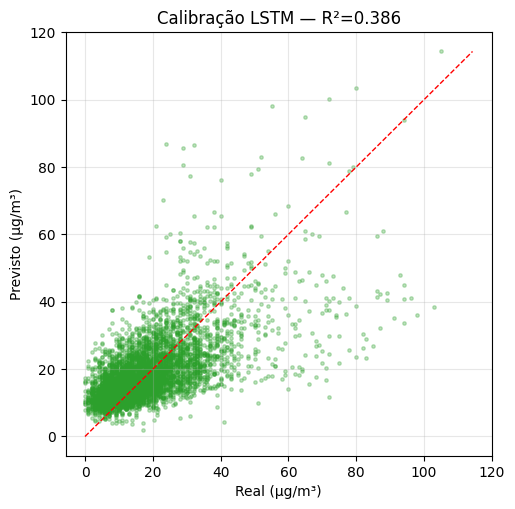

In [22]:

plt.figure(figsize=(5.5, 5.5))
plt.scatter(as_l, ps_l, s=6, alpha=0.3, color='tab:green')
lim = max(as_l.max(), ps_l.max())
plt.plot([0, lim], [0, lim], 'r--', lw=1)
plt.xlabel("Real (µg/m³)"); plt.ylabel("Previsto (µg/m³)")
plt.title(f"Calibração LSTM — R²={r2_score(actual_lstm, pred_lstm):.3f}")
plt.grid(alpha=0.3); plt.show()

# Gráfico 3 — Viés por hora do dia (LSTM)

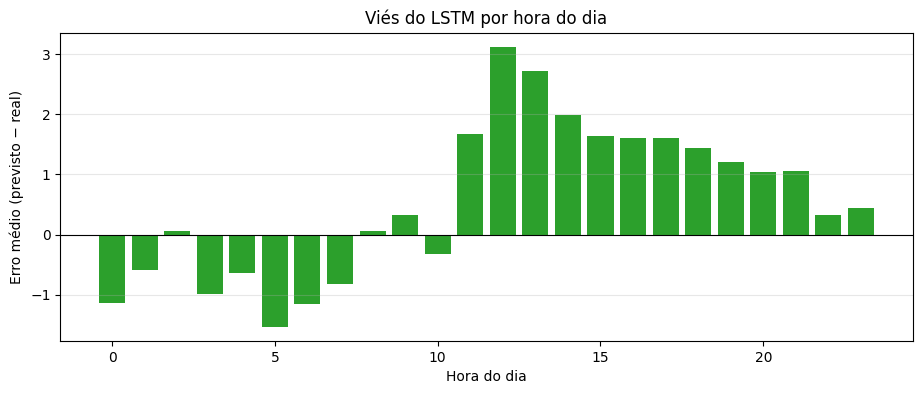

In [23]:
resid_l = (ps_l - as_l)
por_hora_l = resid_l.groupby(resid_l.index.hour).mean()

plt.figure(figsize=(11, 4))
plt.bar(por_hora_l.index, por_hora_l.values, color='tab:green')
plt.axhline(0, color='k', lw=0.8)
plt.xlabel("Hora do dia"); plt.ylabel("Erro médio (previsto − real)")
plt.title("Viés do LSTM por hora do dia")
plt.grid(alpha=0.3, axis='y'); plt.show()

# Gráfico 4 — Degradação do erro ao longo do horizonte (LSTM)

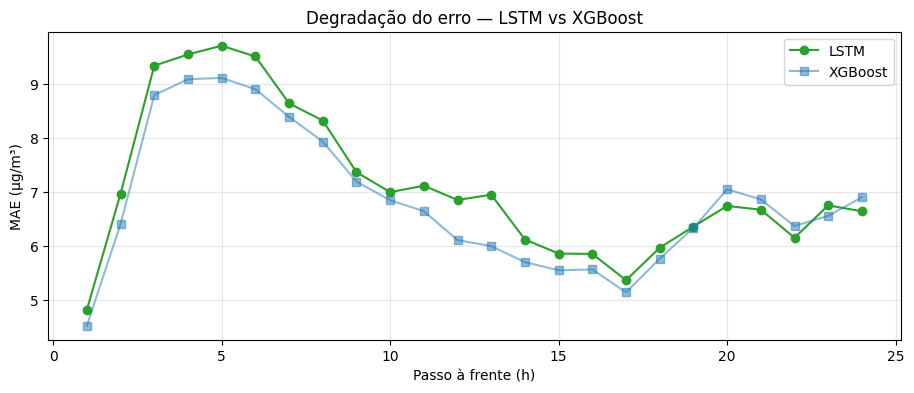

In [24]:
errs_l = []
for fc in hf_lstm:
    pr = scaler_y.inverse_transform(fc)
    ac = target.slice_intersect(pr)
    n = min(len(pr), len(ac))
    errs_l.append(np.abs(pr.values().flatten()[:n] - ac.values().flatten()[:n]))
mae_h_l = np.vstack([e for e in errs_l if len(e) == 24]).mean(axis=0)

plt.figure(figsize=(11, 4))
plt.plot(range(1, 25), mae_h_l, marker='o', color='tab:green', label='LSTM')
plt.plot(range(1, 25), mae_h, marker='s', color='tab:blue', alpha=0.5, label='XGBoost')
plt.xlabel("Passo à frente (h)"); plt.ylabel("MAE (µg/m³)")
plt.title("Degradação do erro — LSTM vs XGBoost")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# LSTM

In [1]:
y_full_s   = y_all_s
cov_full_s = c_all_s
TRAIN_END = pd.Timestamp("2018-01-01")   # treino: até 2017-12-31 23:00
VAL_END   = pd.Timestamp("2019-01-01")   # validação: 2018 inteiro

y_train_s, _rest = y_full_s.split_before(TRAIN_END)
y_val_s,   _     = _rest.split_before(VAL_END)

print("Treino :", y_train_s.start_time(), "→", y_train_s.end_time(), "| n =", len(y_train_s))
print("Valid. :", y_val_s.start_time(),   "→", y_val_s.end_time(),   "| n =", len(y_val_s))
print("Covar. :", cov_full_s.start_time(),"→", cov_full_s.end_time(),"| n =", len(cov_full_s))

NameError: name 'y_all_s' is not defined

In [ ]:
from darts.models import RNNModel
from pytorch_lightning.callbacks import EarlyStopping
early_stopper = EarlyStopping(monitor="val_loss", patience=8, min_delta=1e-4, mode="min", verbose=True,
)

lstm = RNNModel(
    model="LSTM",
    input_chunk_length=168,     # lookback de 1 semana (igual antes → comparação justa)
    training_length=192,        # = lookback + 24h de horizonte
    hidden_dim=64,              # ↑ capacidade
    n_rnn_layers=2,             # ↑ profundidade
    dropout=0.2,                # regularização
    n_epochs=50,                # teto; o EarlyStopping decide o real
    batch_size=64,
    optimizer_kwargs={"lr": 1e-3},
    add_encoders=add_encoders,
    random_state=42,
    model_name="lstm_tuned",
    force_reset=True,           # permite re-rodar a célula sem erro de nome
    pl_trainer_kwargs={
        "callbacks": [early_stopper],
        "accelerator": "cpu",
        "enable_progress_bar": True,
    },
)

lstm.fit(
    series=y_train_s,
    future_covariates=cov_full_s,
    val_series=y_val_s,
    val_future_covariates=cov_full_s,
)

bs = early_stopper.best_score
bs = float(bs) if bs is not None else float("nan")
print(f"\nParou na época {early_stopper.stopped_epoch} | melhor val_loss = {bs:.5f}")